In [77]:
%reset
# 모듈 import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Once deleted, variables cannot be recovered. Proceed (y/[n])? y


In [78]:
# 데이터 로딩
df = pd.read_csv('/content/drive/MyDrive/KDThome/santander-customer-transaction-prediction/train.csv')

In [79]:
from scipy import stats
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import classification_report

In [80]:
# 데이터셋 구성
df_1 = df[[
    'target','var_6', 'var_81', 'var_53', 'var_12', 'var_99', 'var_13', 'var_148', 'var_166', 'var_22', 'var_2', 'var_110', 'var_146', 'var_139', 'var_173', 'var_165', 'var_190', 'var_174', 'var_26', 'var_164', 'var_67', 'var_76', 'var_18', 'var_184', 'var_149', 'var_118'
]]

display(df_1.head())
df_1.info()


,target,var_6,var_81,var_53,var_12,var_99,var_13,var_148,var_166,var_22,...,var_190,var_174,var_26,var_164,var_67,var_76,var_18,var_184,var_149,var_118
0,0,5.1187,13.8372,5.1736,14.0137,-3.4132,0.5745,4.0288,2.7004,2.5791,...,4.4354,18.5618,-5.1488,6.6760,22.4321,-2.3440,4.2840,25.8398,17.9244,-13.4221
1,0,5.6208,18.1782,6.6885,14.0239,0.6939,8.4135,4.2578,3.2003,8.5524,...,7.6421,30.2645,-11.7684,-5.0121,7.9344,3.2709,7.8000,22.5441,-4.4223,-11.5100
2,0,6.9427,15.7811,6.4059,14.1929,-0.0269,7.3124,4.0714,3.2790,1.2145,...,2.9057,25.6820,-7.9940,-1.0410,9.8565,4.5048,4.7011,23.0866,-1.2681,-17.2738
3,0,5.8428,10.5404,5.2091,13.8463,1.9480,11.9704,3.7613,2.5881,6.8202,...,4.4666,14.7483,0.8135,-11.0882,23.6143,11.6875,15.9426,-0.4639,2.3701,3.5732
4,0,5.9405,13.3317,5.7555,13.8481,0.6715,7.8895,3.7574,3.2304,10.1102,...,-1.4905,18.4685,3.1736,6.5769,1.6184,1.0273,6.5263,11.8503,9.9110,13.8224


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 26 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   target   200000 non-null  int64  
 1   var_6    200000 non-null  float64
 2   var_81   200000 non-null  float64
 3   var_53   200000 non-null  float64
 4   var_12   200000 non-null  float64
 5   var_99   200000 non-null  float64
 6   var_13   200000 non-null  float64
 7   var_148  200000 non-null  float64
 8   var_166  200000 non-null  float64
 9   var_22   200000 non-null  float64
 10  var_2    200000 non-null  float64
 11  var_110  200000 non-null  float64
 12  var_146  200000 non-null  float64
 13  var_139  200000 non-null  float64
 14  var_173  200000 non-null  float64
 15  var_165  200000 non-null  float64
 16  var_190  200000 non-null  float64
 17  var_174  200000 non-null  float64
 18  var_26   200000 non-null  float64
 19  var_164  200000 non-null  float64
 20  var_67   200000 non-null  

In [81]:
# 결측치는 없고
# 이상치만 존재. 제거하지 않고 변환 (IQR + 클리핑)

# 이상치 변환 함수
def clip_outliers_iqr(df):
  df_clipped = df.copy()
  for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    df_clipped[col] = df[col].clip(lower, upper)

  return df_clipped

target_out = df_1.drop('target', axis=1, inplace=False)
df_2 = clip_outliers_iqr(target_out)

df_3 = pd.concat([df_2,df_1['target']], axis=1)

print(df_3.shape)
print(df_3['target'].value_counts())

(200000, 26)
target
0    179902
1     20098
Name: count, dtype: int64


In [82]:
# 새로운 feature 추가
df_3['new_feature_1'] = df_3['var_6'] + df_3['var_81']

In [83]:
#print(df_3.corr()['target'])
df_3.describe()

,var_6,var_81,var_53,var_12,var_99,var_13,var_148,var_166,var_22,var_2,...,var_26,var_164,var_67,var_76,var_18,var_184,var_149,var_118,target,new_feature_1
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,...,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,5.408948,14.718656,6.008586,14.023973,-0.746224,8.530234,3.990689,2.963328,4.304951,10.715189,...,-4.054879,-2.871905,11.944471,6.050887,15.244000,12.756560,5.295816,-5.303700,0.100490,20.127604
std,0.866390,2.298343,0.764700,0.190043,1.862213,4.639531,0.199021,0.369663,2.846074,2.640765,...,5.920146,5.457780,7.353212,7.934195,7.851179,9.317548,10.370608,8.792657,0.300653,2.453494
min,2.914750,8.525737,3.774650,13.488700,-6.058250,-5.730162,3.436600,1.885250,-3.983800,3.031137,...,-20.669013,-19.720463,-8.673475,-16.237450,-8.575113,-15.025975,-23.790337,-30.427325,0.000000,11.908400
25%,4.767700,13.214775,5.435600,13.894000,-2.106200,5.072800,3.853600,2.699000,2.182400,8.722475,...,-8.321725,-7.094025,6.753200,0.596300,9.177950,5.663300,-1.903200,-11.587850,0.000000,18.518800
50%,5.385100,14.844500,6.027800,14.025500,-0.771300,8.604250,3.996000,2.960200,4.275150,10.580000,...,-4.196900,-2.637800,11.922000,6.297800,15.196250,12.521000,5.283250,-5.189500,0.000000,20.231600
75%,6.003000,16.340800,6.542900,14.164200,0.528500,12.274775,4.131600,3.241500,6.293200,12.516700,...,-0.090200,1.323600,17.037650,11.818800,21.013325,19.456150,12.688225,0.971800,0.000000,21.840625
max,7.855950,21.029838,8.203850,14.569500,4.480550,22.331500,4.548600,4.055250,12.459400,18.208038,...,12.257088,12.119300,32.464325,28.652550,38.766388,40.145425,34.575362,19.811275,1.000000,28.536938


In [84]:
# 데이터 분리
x_data = df_3.drop('target', axis=1, inplace=False).values
t_data = df_3['target'].values

In [90]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x_data, t_data, test_size=0.1, stratify=t_data
)

In [91]:
# 3. 정규화 (train 기준으로 fit)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [92]:
# 4. 오버샘플링 (정규화된 train에만 적용)
sm = SMOTE(random_state=42)
x_train_sm, y_train_sm = sm.fit_resample(x_train, y_train)

In [93]:
# 5. 모델 학습
xgb_model = XGBClassifier(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)
xgb_model.fit(x_train_sm, y_train_sm)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [97]:
# 5. 예측 및 평가
y_pred = xgb_model.predict(x_test)
print("🔸 [F] 평균차 + 상관계수 + 중요도 기반 조합 + 이상치처리 모델 성능 🔸")
print(classification_report(y_test, y_pred, digits=4))

🔸 [F] 평균차 + 상관계수 + 중요도 기반 조합 + 이상치처리 모델 성능 🔸
              precision    recall  f1-score   support

           0     0.9371    0.6877    0.7932     17990
           1     0.1734    0.5866    0.2677      2010

    accuracy                         0.6775     20000
   macro avg     0.5552    0.6371    0.5305     20000
weighted avg     0.8603    0.6775    0.7404     20000



In [ ]:
# 평가용 데이터 불러오기
test = pd.read_csv('/content/drive/MyDrive/KDThome/santander-customer-transaction-prediction/test.csv')

In [76]:
print(np.any(np.isnan(x_data)))  # NaN 값이 있는지 확인
print(np.any(np.isinf(x_data)))

False
True


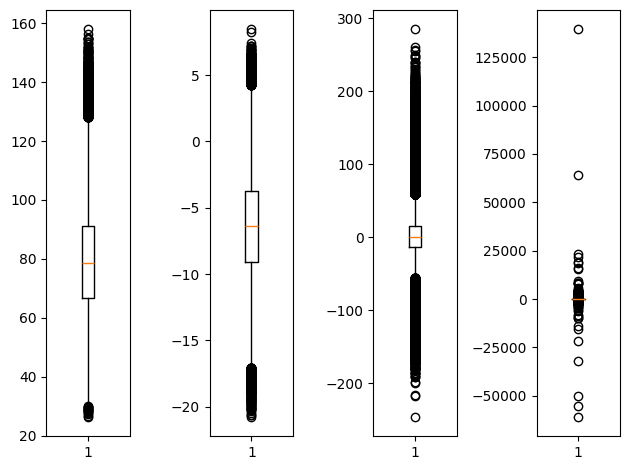

In [64]:
# 새로운 컬럼은 이상치 확인
fig = plt.figure()
ax1 = fig.add_subplot(1,4,1)
ax2 = fig.add_subplot(1,4,2)
ax3 = fig.add_subplot(1,4,3)
ax4 = fig.add_subplot(1,4,4)

ax1.boxplot(df_3['new_feature_2'])
ax2.boxplot(df_3['new_feature_4'])
ax3.boxplot(df_3['new_feature_6'])
ax4.boxplot(df_3['new_feature_8'])
plt.tight_layout()
plt.show()


In [37]:
# 새로운 컬럼은 로그변환 고고
df_4['new_feature_1'] = np.log1p(df_4['new_feature_1'])
df_4['new_feature_3'] = np.log1p(df_4['new_feature_3'])
df_4['new_feature_5'] = np.log1p(df_4['new_feature_5'])
df_4['new_feature_7'] = np.log1p(df_4['new_feature_7'])

df_5 = df_4.drop(['new_feature_1','new_feature_3','new_feature_5','new_feature_7'], axis=1, inplace=False)


/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
df_3['new_feature_2'] = df_3['var_6'] * df_3['var_81']
df_3['new_feature_3'] = df_3['var_99'] + df_3['var_146']
df_3['new_feature_4'] = df_3['var_22'] - df_3['var_2']
df_3['new_feature_5'] = df_3['var_22'] / (df_3['var_2'] + 1)
df_3['new_feature_6'] = df_3['var_164'] * df_3['var_173']
df_3['new_feature_7'] = df_3['var_148'] + df_3['var_166']
df_3['new_feature_8'] = df_3['var_110'] / (df_3['var_190'] + 1)

# new_feature_1 ~ new_feature_8을 소수점 4자리로 반올림
feature_cols = [f'new_feature_{i}' for i in range(1, 9)]
df_3[feature_cols] = df_3[feature_cols].round(4)

df_3.head()  # 결과 확인